In [2]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/GSLLevelVol.csv')

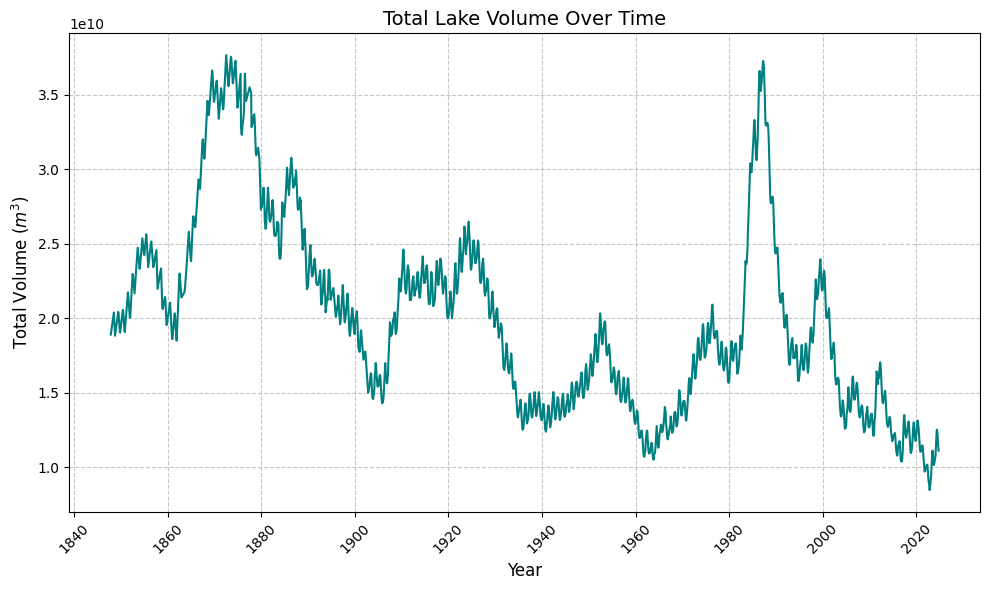

In [4]:
# Convert the 'Date' column from strings to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date to ensure the line plot connects correctly
df = df.sort_values('Date')

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Total_vol_m3'], linestyle='-', color='teal')

# Formatting the labels
plt.title('Total Lake Volume Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Volume ($m^3$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df.head()

,Date,S_level_ft,N_level_ft,S_level_m,N_level_m,S_area_m2,N_area_m2,S_vol_m3,N_vol_m3,Total_vol_m3,natlev_m,natlev_ft
0,1847-11-01,4199.864615,4199.864615,1280.118735,1280.118735,2.643110e+09,1.547986e+09,1.194469e+10,6.958589e+09,1.890328e+10,1280.118735,4199.864615
1,1847-12-01,4200.003077,4200.003077,1280.160938,1280.160938,2.668944e+09,1.555834e+09,1.205525e+10,7.023666e+09,1.907892e+10,1280.160938,4200.003077
2,1848-01-01,4200.146154,4200.146154,1280.204548,1280.204548,2.701545e+09,1.559613e+09,1.217513e+10,7.091888e+09,1.926702e+10,1280.204548,4200.146154
3,1848-02-01,4200.289231,4200.289231,1280.248158,1280.248158,2.734145e+09,1.563391e+09,1.229501e+10,7.160110e+09,1.945512e+10,1280.248158,4200.289231
4,1848-03-01,4200.423077,4200.423077,1280.288954,1280.288954,2.764642e+09,1.566926e+09,1.240715e+10,7.223930e+09,1.963108e+10,1280.288954,4200.423077


In [6]:
df.shape

(2124, 12)

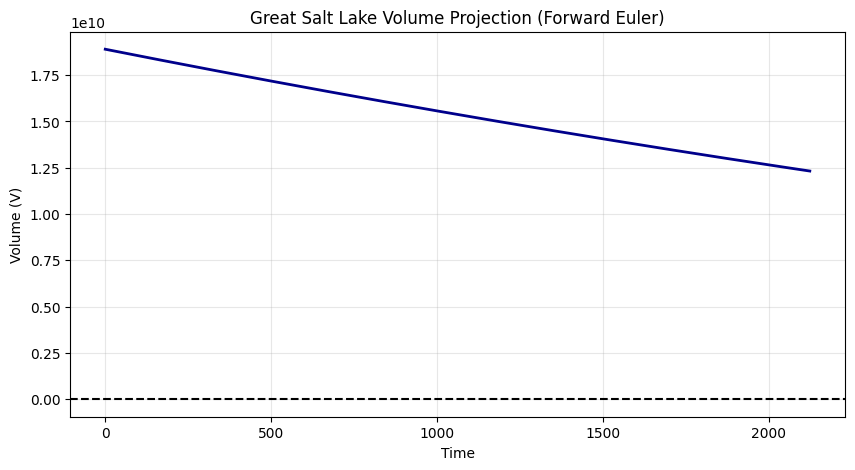

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def gsl_model_derivative(t, V, k_evap):
    """
    The right-hand side of the ODE: dV/dt = - E * A(V)
    Assume a simplified area-volume relationship: A = V^(2/3)
    """
    # Geometric assumption for a basin shape
    surface_area = V**(2/3)
    
    # dV/dt calculation
    dv_dt = -k_evap * surface_area
    return dv_dt

def solve_evaporation_euler(V0, k_evap, t0, tn, steps):
    """
    Specifically implements Forward Euler for the lake model.
    """
    h = (tn - t0) / steps
    t_values = np.linspace(t0, tn, steps + 1)
    v_values = np.zeros(steps + 1)
    v_values[0] = V0

    for i in range(steps):
        # Forward Euler Step: V_{n+1} = V_n + h * f(t_n, V_n)
        derivative = gsl_model_derivative(t_values[i], v_values[i], k_evap)
        v_values[i+1] = v_values[i] + h * derivative
        
        # Physical constraint: Lake volume cannot be negative
        if v_values[i+1] < 0:
            v_values[i+1] = 0
            
    return t_values, v_values

# Parameters based on your project needs
initial_volume = 1.890328e+10  # Initial lake volume
evap_coeff = 0.5         # Rate of evaporation loss
#avg_inflow = 10.0        # Average water entering the lake
time_start = 0
time_end = 2124            # e.g., 24 months or years
num_steps = 2124

# Run the simulation
t, v = solve_evaporation_euler(initial_volume, evap_coeff, time_start, time_end, num_steps)

# Plotting results
plt.figure(figsize=(10, 5))
plt.plot(t, v, color='darkblue', linewidth=2)
plt.axhline(0, color='black', linestyle='--') # Shoreline/Empty mark
plt.title("Great Salt Lake Volume Projection (Forward Euler)")
plt.xlabel("Time")
plt.ylabel("Volume (V)")
plt.grid(alpha=0.3)
plt.show()

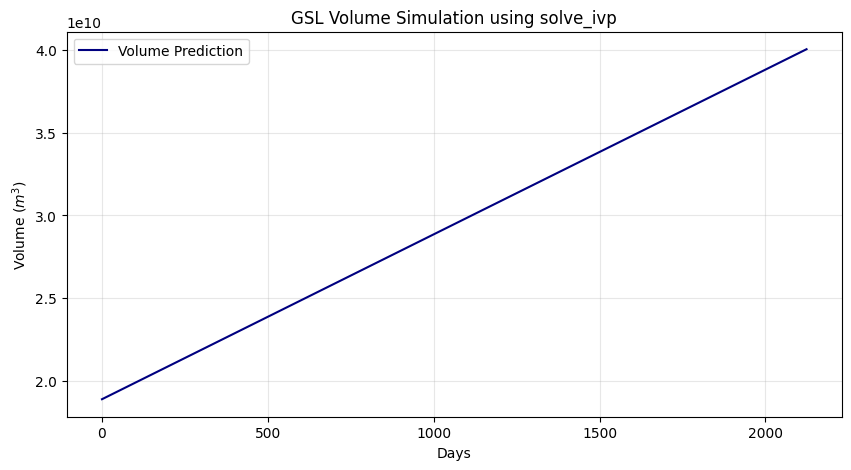

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the derivative function
def lake_model(t, V, k_evap, inflow):
    current_volume = V[0]
    
    # Simple area-volume relationship: A = V^(2/3)
    surface_area = current_volume**(2/3)
    
    # dV/dt = Inflow - (Evaporation Rate * Surface Area)
    dv_dt = inflow - (k_evap * surface_area)
    
    return [dv_dt]

# 2. Set Parameters and Initial Conditions
initial_volume = [1.89e10]  # Starting value from your data
t_span = (0, 2124)           # Solve for 365 days
k = 0.005                   # Evaporation coefficient
inflow_rate = 1.0e7         # Average daily inflow

# Solve the Initial Value Problem
sol = solve_ivp(
    lake_model, 
    t_span, 
    initial_volume, 
    args=(k, inflow_rate),
    method='RK45',          
    t_eval=np.linspace(0, 2124, 2124)
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label='Volume Prediction', color='navy')
plt.title('GSL Volume Simulation using solve_ivp')
plt.xlabel('Days')
plt.ylabel('Volume ($m^3$)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()